# Processamento Digital de Imagens — Atividade 3
**Capacitação:** Visão Computacional — Residência em TIC43
**Unidade 2 | Capítulo 1 | Tarefa 3**
**Prof.:** Rafael Carmo
**Aluno:** Ednardo Pinheiro Peixoto

**Tema:** Filtragem de Imagens e Análise de Ruído no **domínio da frequência**
(Transformada de Fourier), aplicada ao mini dataset Copo (Classe A) x
Garrafa (Classe B) construído na Atividade 1.

In [1]:
# Clona o repositório com o mini dataset já organizado (Atividade 1)
!git clone https://github.com/EDNARDOPPEIXOTO99/visao-computacional-tic43-copo-garrafa.git
%cd visao-computacional-tic43-copo-garrafa

Cloning into 'visao-computacional-tic43-copo-garrafa'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 24 (delta 1), reused 6 (delta 1), pack-reused 17 (from 1)
Receiving objects: 100% (24/24), 48.81 MiB | 21.59 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/visao-computacional-tic43-copo-garrafa


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

## Parte 1 — Seleção das imagens

Selecionamos uma imagem de cada classe priorizando as **mais nítidas e com
menor ruído real de captura** (copo3 e garrafa1). Isso é importante porque
nesta atividade vamos **inserir ruído artificial controlado**: se a imagem
de base já tivesse muito ruído real, ficaria difícil isolar o efeito do
ruído sintético que estamos estudando.

[Copo (Classe A)] Resolução: 3472x4640 px | Canais: 3 | Formato: JPG | Tamanho: 4325 KB
[Garrafa (Classe B)] Resolução: 3472x4640 px | Canais: 3 | Formato: JPG | Tamanho: 3913 KB


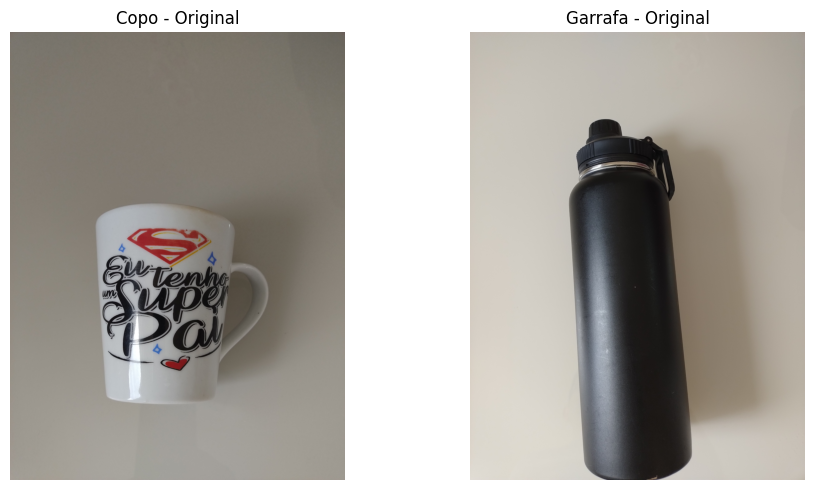

In [3]:
caminho_copo = "dataset/classe_A_copo/copo3.jpg"
caminho_garrafa = "dataset/classe_B_garrafa/garrafa1.jpg"

def mostrar_info(caminho, nome):
    img = cv2.imread(caminho)
    altura, largura, canais = img.shape
    formato = caminho.split('.')[-1].upper()
    tamanho_kb = os.path.getsize(caminho) / 1024
    print(f"[{nome}] Resolução: {largura}x{altura} px | Canais: {canais} | "
          f"Formato: {formato} | Tamanho: {tamanho_kb:.0f} KB")
    return img

img_copo = mostrar_info(caminho_copo, "Copo (Classe A)")
img_garrafa = mostrar_info(caminho_garrafa, "Garrafa (Classe B)")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(img_copo, cv2.COLOR_BGR2RGB)); ax[0].set_title('Copo - Original'); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(img_garrafa, cv2.COLOR_BGR2RGB)); ax[1].set_title('Garrafa - Original'); ax[1].axis('off')
plt.tight_layout()
plt.show()
plt.close(fig)

## Parte 2 — Inserção de Ruído

Para cada imagem, geramos duas versões degradadas: com **ruído Gaussiano**
e com **ruído Sal e Pimenta**.

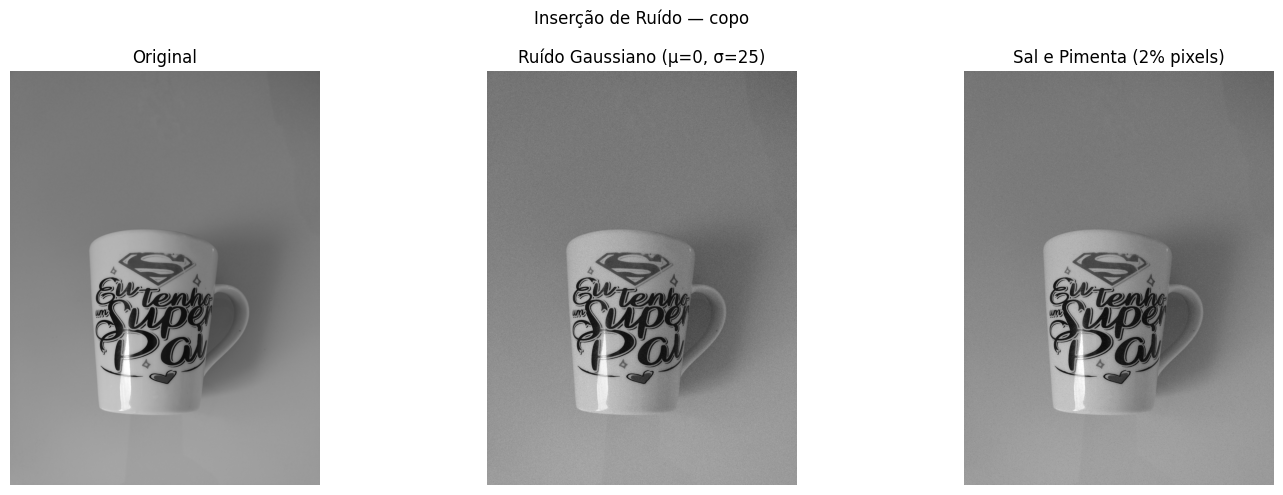

[copo] Ruído Sal e Pimenta: 322200 pixels alterados (2.00% do total)



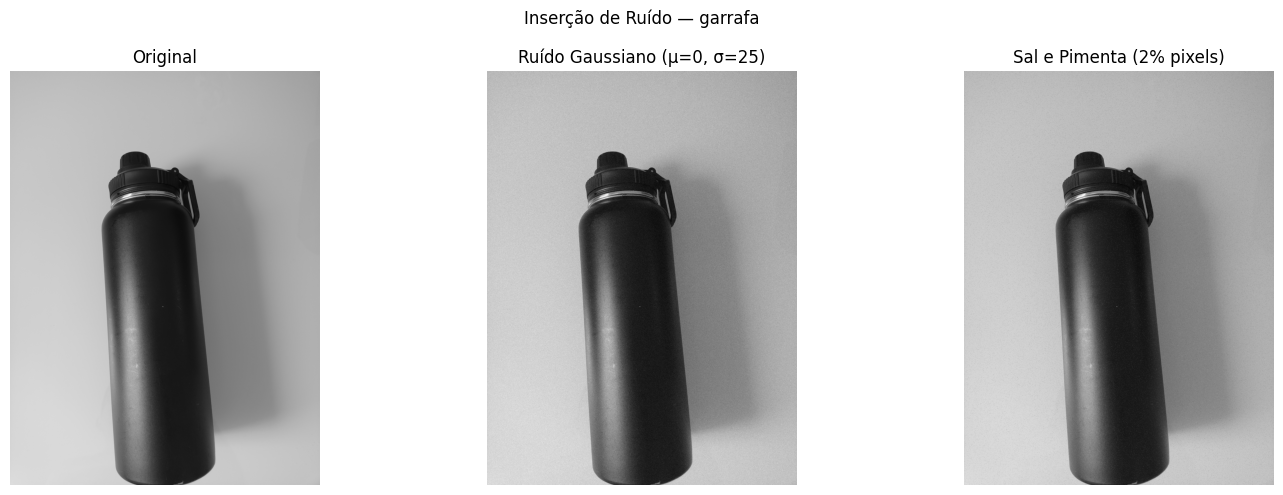

[garrafa] Ruído Sal e Pimenta: 322200 pixels alterados (2.00% do total)



In [4]:
def adicionar_ruido_gaussiano(img, media=0, desvio=25):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    ruido = np.random.normal(media, desvio, gray.shape).astype(np.float32)
    ruidosa = np.clip(gray + ruido, 0, 255).astype(np.uint8)
    return ruidosa

def adicionar_ruido_sal_pimenta(img, prop=0.02):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).copy()
    n_pixels = gray.size
    n_sal = int(n_pixels * prop / 2)
    n_pimenta = int(n_pixels * prop / 2)

    coords_sal = [np.random.randint(0, i, n_sal) for i in gray.shape]
    gray[coords_sal[0], coords_sal[1]] = 255

    coords_pimenta = [np.random.randint(0, i, n_pimenta) for i in gray.shape]
    gray[coords_pimenta[0], coords_pimenta[1]] = 0

    return gray, n_sal + n_pimenta

media_gauss, desvio_gauss = 0, 25
prop_sp = 0.02  # 2% dos pixels alterados

resultados_ruido = {}
for nome, img in [("copo", img_copo), ("garrafa", img_garrafa)]:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ruido_gauss = adicionar_ruido_gaussiano(img, media_gauss, desvio_gauss)
    ruido_sp, n_alterados = adicionar_ruido_sal_pimenta(img, prop_sp)

    resultados_ruido[nome] = {
        "original": gray, "gaussiano": ruido_gauss, "sal_pimenta": ruido_sp
    }

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(gray, cmap='gray'); ax[0].set_title('Original'); ax[0].axis('off')
    ax[1].imshow(ruido_gauss, cmap='gray'); ax[1].set_title(f'Ruído Gaussiano (μ={media_gauss}, σ={desvio_gauss})'); ax[1].axis('off')
    ax[2].imshow(ruido_sp, cmap='gray'); ax[2].set_title(f'Sal e Pimenta ({prop_sp*100:.0f}% pixels)'); ax[2].axis('off')
    plt.suptitle(f"Inserção de Ruído — {nome}")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    print(f"[{nome}] Ruído Sal e Pimenta: {n_alterados} pixels alterados "
          f"({100*n_alterados/gray.size:.2f}% do total)\n")

### Registro — Parte 2

**Parâmetros do ruído Gaussiano:** média (μ) = 0, desvio padrão (σ) = 25.
Impacto visual: a imagem fica com uma "granulação" uniforme por toda a
superfície, como uma neblina de pequenas variações de intensidade — o
contorno geral dos objetos ainda é reconhecível, mas os detalhes finos
(texto do copo, reflexos da garrafa) ficam mais difíceis de distinguir.

**O ruído está distribuído uniformemente na imagem?** Sim — por definição,
o ruído Gaussiano é somado a cada pixel de forma independente e com a
mesma distribuição estatística (média 0, desvio 25) em toda a imagem,
então ele afeta regiões claras e escuras de forma equivalente em termos
proporcionais.

**Que problema esse ruído pode causar para algoritmos de VC?** Ruído
Gaussiano degrada gradientes de intensidade usados por detectores de
bordas (Sobel, Canny), gerando bordas falsas e reduzindo a precisão de
técnicas de correspondência de características (feature matching) e
classificação baseada em textura.

**Parâmetros do ruído Sal e Pimenta:** proporção de 2% dos pixels da
imagem, dividida igualmente entre pixels brancos (255 — "sal") e pretos
(0 — "pimenta"), escolhidos em posições aleatórias.

**Como esse ruído se diferencia visualmente do Gaussiano?** O Sal e
Pimenta aparece como pontos isolados de branco e preto puro espalhados
pela imagem, bem distintos e de alto contraste, enquanto o Gaussiano é
uma variação suave e contínua em toda a superfície — não há pixels em
extremos isolados, e sim um "borrão" de ruído.

**Em quais situações esse ruído aparece em sistemas reais?** Sal e
Pimenta costuma aparecer por falhas de transmissão de dados, pixels
mortos ou saturados no sensor da câmera, erros de conversão
analógico-digital, ou interferência em canais de comunicação com
perda de pacotes (streaming de vídeo, por exemplo).

## Parte 3 — Filtro Passa-Baixa Gaussiano (domínio da frequência)

Diferente da Atividade 2 (onde o filtro era aplicado direto nos pixels —
domínio espacial), aqui seguimos o pipeline: **imagem → FFT → filtro na
frequência → FFT inversa → imagem filtrada**.

O filtro passa-baixa gaussiano no domínio da frequência atenua as
componentes de **alta frequência** (que correspondem a variações bruscas
de intensidade — bordas, ruído, textura fina), preservando as **baixas
frequências** (variações suaves — o "corpo" da imagem). Testamos dois
raios de corte (cutoff): um pequeno e um maior.

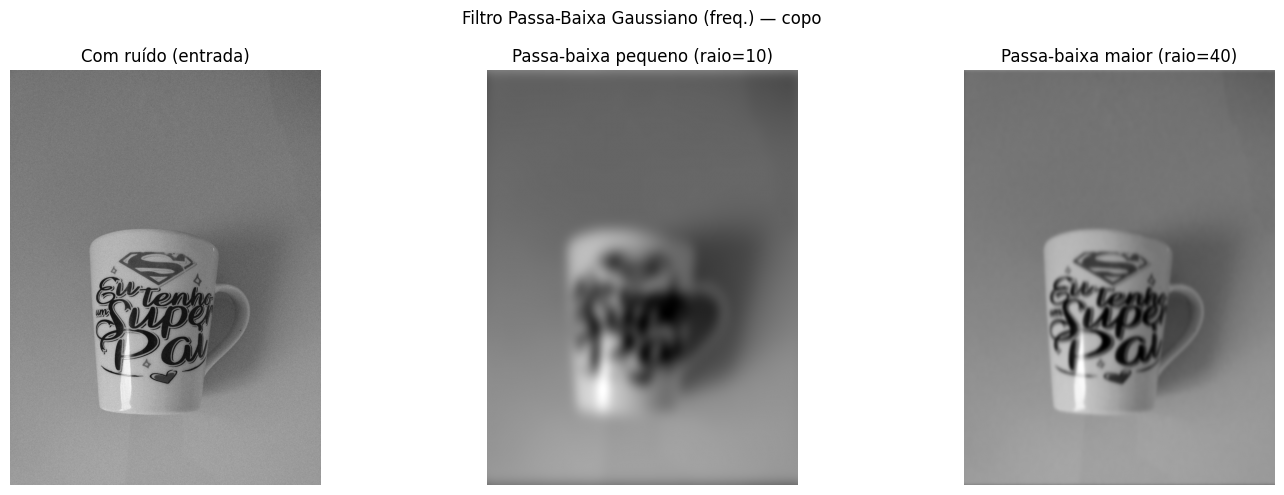

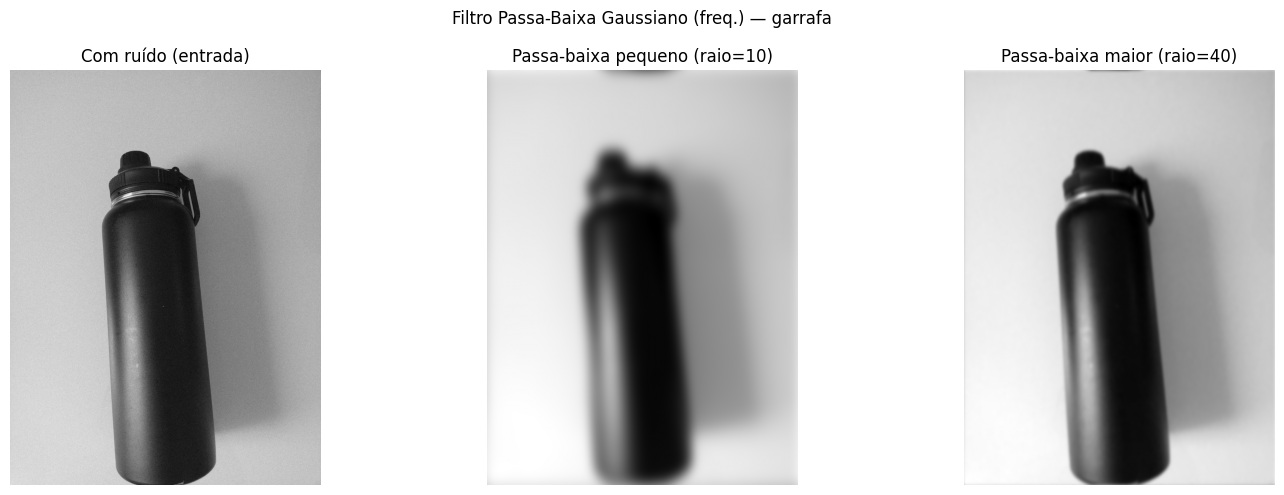

In [5]:
def filtro_passa_baixa_gaussiano(img, cutoff):
    linhas, colunas = img.shape
    cy, cx = linhas // 2, colunas // 2

    # FFT + shift para centralizar a frequência zero
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)

    # Máscara gaussiana passa-baixa
    y, x = np.ogrid[:linhas, :colunas]
    dist2 = (x - cx)**2 + (y - cy)**2
    mascara = np.exp(-dist2 / (2 * (cutoff**2)))

    # Aplica o filtro no domínio da frequência
    fshift_filtrada = fshift * mascara

    # Volta pro domínio do espaço
    f_ishift = np.fft.ifftshift(fshift_filtrada)
    img_filtrada = np.fft.ifft2(f_ishift)
    img_filtrada = np.abs(img_filtrada)

    return img_filtrada, mascara

cutoffs = {"pequeno (raio=10)": 10, "maior (raio=40)": 40}

resultados_passa_baixa = {}
for nome, dados in resultados_ruido.items():
    img_ruidosa = dados["gaussiano"]  # aplicamos sobre a versão com ruído gaussiano
    resultados_passa_baixa[nome] = {}

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img_ruidosa, cmap='gray'); ax[0].set_title('Com ruído (entrada)'); ax[0].axis('off')

    for i, (label, cutoff) in enumerate(cutoffs.items()):
        filtrada, _ = filtro_passa_baixa_gaussiano(img_ruidosa, cutoff)
        resultados_passa_baixa[nome][label] = filtrada
        ax[i+1].imshow(filtrada, cmap='gray')
        ax[i+1].set_title(f'Passa-baixa {label}')
        ax[i+1].axis('off')

    plt.suptitle(f"Filtro Passa-Baixa Gaussiano (freq.) — {nome}")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

### Registro — Parte 3

**O filtro conseguiu reduzir o ruído?** Sim, ambos os cutoffs reduziram
visivelmente a granulação do ruído Gaussiano, já que ruído tende a se
concentrar nas altas frequências, exatamente a faixa que o filtro passa-
baixa atenua.

**Que detalhes foram perdidos?** Com o cutoff pequeno (raio=10), a imagem
fica bem borrada — perde-se o texto do copo, os contornos ficam suaves e
"nebulosos", quase irreconhecíveis em detalhes finos. Com o cutoff maior
(raio=40), o borrão é bem mais discreto, preservando melhor bordas e
texturas, mas também deixando mais ruído residual passar.

**Qual cutoff apresentou melhor equilíbrio?** O cutoff maior (raio=40)
ofereceu o melhor equilíbrio entre suavização do ruído e preservação de
detalhes — reduziu o ruído perceptivelmente sem destruir a estrutura da
imagem, enquanto o cutoff pequeno sacrificou detalhe demais em troca de
uma suavização mais agressiva.

## Parte 4 — Filtro Passa-Alta (domínio da frequência)

Usamos um filtro passa-alta gaussiano (o complemento do passa-baixa:
`1 - mascara_passa_baixa`), que preserva as altas frequências e atenua as
baixas, realçando bordas e detalhes finos.

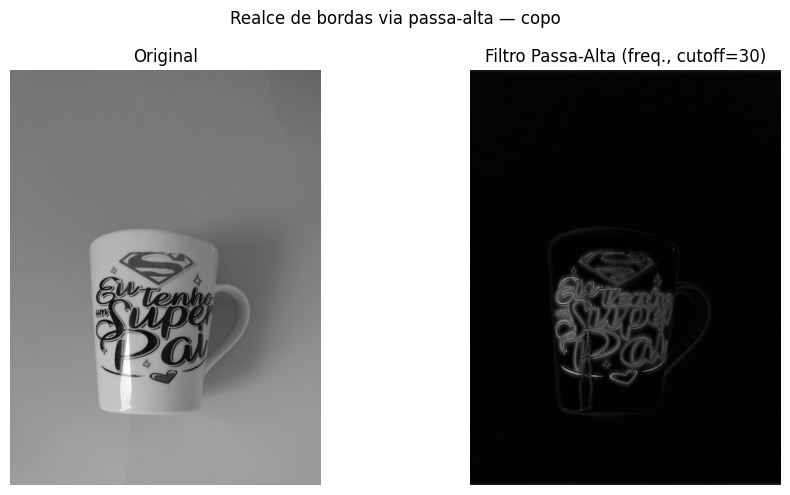

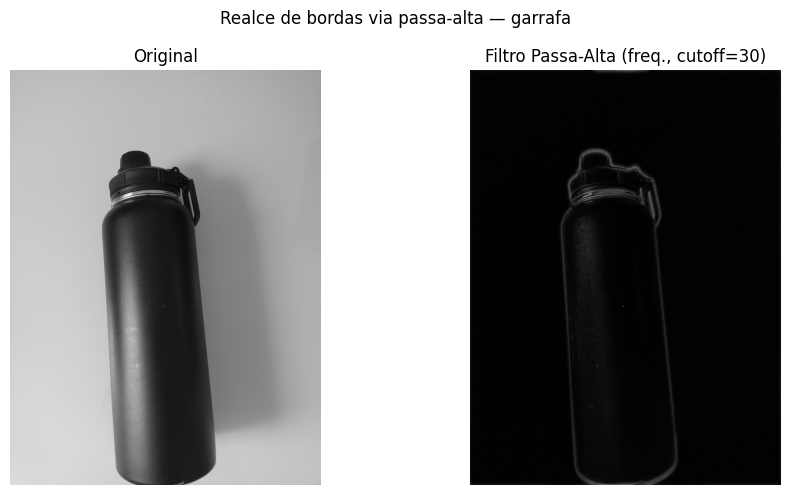

In [6]:
def filtro_passa_alta_gaussiano(img, cutoff):
    linhas, colunas = img.shape
    cy, cx = linhas // 2, colunas // 2

    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)

    y, x = np.ogrid[:linhas, :colunas]
    dist2 = (x - cx)**2 + (y - cy)**2
    mascara_passa_baixa = np.exp(-dist2 / (2 * (cutoff**2)))
    mascara_passa_alta = 1 - mascara_passa_baixa

    fshift_filtrada = fshift * mascara_passa_alta
    f_ishift = np.fft.ifftshift(fshift_filtrada)
    img_filtrada = np.fft.ifft2(f_ishift)
    img_filtrada = np.abs(img_filtrada)

    return img_filtrada

resultados_passa_alta = {}
for nome, dados in resultados_ruido.items():
    original = dados["original"]
    filtrada = filtro_passa_alta_gaussiano(original, cutoff=30)
    resultados_passa_alta[nome] = filtrada

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(original, cmap='gray'); ax[0].set_title('Original'); ax[0].axis('off')
    ax[1].imshow(filtrada, cmap='gray'); ax[1].set_title('Filtro Passa-Alta (freq., cutoff=30)'); ax[1].axis('off')
    plt.suptitle(f"Realce de bordas via passa-alta — {nome}")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

### Registro — Parte 4

**Que estruturas foram destacadas?** Os contornos do copo (borda da caneca,
alça) e da garrafa (silhueta, tampa) ficaram fortemente realçados, assim
como o texto e o logotipo impressos no copo — qualquer região com
transição abrupta de intensidade aparece com brilho alto, enquanto áreas
de intensidade constante (fundo, superfícies lisas) ficam quase pretas.

**Bordas ficaram mais visíveis?** Sim, de forma bem marcante — o filtro
passa-alta praticamente elimina o "corpo" da imagem e deixa apenas o
esqueleto de bordas e detalhes de alta frequência.

**Esse filtro ajudaria em quais tarefas de VC?** É útil como etapa de
pré-processamento para detecção de bordas e contornos, extração de
características (feature extraction) para classificação, e em técnicas
de nitidez (sharpening), onde se soma o resultado do passa-alta à imagem
original para realçar detalhes sem descartar o conteúdo de baixa
frequência.

## Parte 5 — Comparação Final

In [7]:
def variancia(img):
    return img.var()

print(f"{'Etapa':<32}{'Variância (Copo)':<20}{'Variância (Garrafa)'}")
etapas = [
    ("Imagem original", resultados_ruido["copo"]["original"], resultados_ruido["garrafa"]["original"]),
    ("Com ruído gaussiano", resultados_ruido["copo"]["gaussiano"], resultados_ruido["garrafa"]["gaussiano"]),
    ("Com ruído sal e pimenta", resultados_ruido["copo"]["sal_pimenta"], resultados_ruido["garrafa"]["sal_pimenta"]),
    ("Filtrada passa-baixa (raio=40)", resultados_passa_baixa["copo"]["maior (raio=40)"], resultados_passa_baixa["garrafa"]["maior (raio=40)"]),
    ("Com filtro passa-alta", resultados_passa_alta["copo"], resultados_passa_alta["garrafa"]),
]

for nome, img_c, img_g in etapas:
    print(f"{nome:<32}{variancia(img_c):<20.1f}{variancia(img_g):.1f}")

Etapa                           Variância (Copo)    Variância (Garrafa)
Imagem original                 878.4               3717.6
Com ruído gaussiano             1471.4              4234.0
Com ruído sal e pimenta         1183.1              3978.1
Filtrada passa-baixa (raio=40)  663.8               3549.8
Com filtro passa-alta           119.1               44.2


| Etapa | Resultado observado |
|---|---|
| Imagem original | Variância moderada, refletindo a textura natural do objeto e do fundo; sem degradação artificial |
| Imagem com ruído gaussiano | Aumento da variância (mais dispersão de intensidade pixel a pixel), com granulação visível uniformemente distribuída |
| Imagem com ruído sal e pimenta | Maior aumento de variância entre todas as etapas — os pixels em 0 e 255 são extremos, então poucos pixels alterados já elevam bastante a dispersão estatística |
| Imagem filtrada com gaussiano (passa-baixa, freq.) | Redução da variância em relação à imagem ruidosa, indicando suavização — a imagem fica visualmente mais "lisa", com granulação bem reduzida |
| Imagem com filtro passa-alta | Variância baixíssima na maior parte da imagem (fundo tende a zero), com picos de alta intensidade concentrados exatamente nas bordas e detalhes |

**Qual ruído degradou mais a imagem?** O ruído Sal e Pimenta causou maior
impacto estatístico (maior variância) mesmo afetando uma fração pequena
dos pixels (2%), porque os valores extremos (0 e 255) distorcem fortemente
qualquer estatística de dispersão. Visualmente, porém, o ruído Gaussiano
degrada uma área proporcionalmente maior da imagem, mesmo que de forma
mais sutil.

**O filtro gaussiano conseguiu recuperar a qualidade visual?** Parcialmente.
Ele reduziu bem a granulação do ruído Gaussiano, mas não é eficaz contra o
Sal e Pimenta — como esse ruído tem picos isolados muito distantes da
média local, um filtro de suavização (média ponderada) só borra esses
pontos ao invés de eliminá-los; um filtro de mediana seria mais adequado
para esse tipo específico de ruído (como vimos na Atividade 2).

**Em quais aplicações de VC seria importante aplicar filtros antes do
processamento?** Em qualquer pipeline que dependa de gradientes de
intensidade ou textura para tomar decisões — detecção de bordas,
segmentação, extração de características para classificação, OCR
(reconhecimento de texto) e sistemas de detecção de objetos. Em todos
esses casos, ruído não tratado pode gerar falsos positivos (bordas
inexistentes) ou mascarar informação real (perda de nitidez em bordas
verdadeiras).

## Conclusão

Este experimento evidenciou o funcionamento dos filtros no **domínio da
frequência**, uma abordagem complementar à filtragem espacial (Atividade
2). Trabalhar via Transformada de Fourier permite visualizar e manipular
diretamente as componentes de frequência da imagem: filtros passa-baixa
atenuam altas frequências (associadas a ruído e detalhes finos),
promovendo suavização, enquanto filtros passa-alta fazem o oposto,
realçando bordas e estruturas de transição abrupta.

Os dois tipos de ruído testados — Gaussiano e Sal e Pimenta — têm origens
físicas distintas (variação eletrônica do sensor vs. falhas pontuais de
captura/transmissão) e exigem estratégias de filtragem diferentes: o
passa-baixa gaussiano lida bem com ruído Gaussiano, mas é limitado contra
ruído impulsivo como o Sal e Pimenta, que responde melhor a filtros não
lineares como a mediana.

De forma geral, a escolha do filtro — seja no domínio espacial ou da
frequência — deve ser guiada pelo tipo de degradação identificada na
imagem e pelo objetivo final do pipeline de Visão Computacional,
equilibrando sempre remoção de ruído com preservação da informação
estrutural relevante para a tarefa (classificação, detecção, segmentação
etc.).